In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/SE4050_FER_Project/archive.zip"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        bad_file = zip_ref.testzip()

        if bad_file is None:
            print("ZIP file is valid!")
        else:
            print("Corrupted file found:", bad_file)

except zipfile.BadZipFile:
    print("The ZIP file is corrupted.")

ZIP file is valid!


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/SE4050_FER_Project/archive.zip"
extract_path = "/content/fer2013"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("FER-2013 extracted successfully!")

FER-2013 extracted successfully!


In [5]:
print(os.listdir("/content/fer2013"))


['train', 'test']


In [6]:
train_path = "/content/fer2013/train"
test_path = "/content/fer2013/test"

print("Training classes:")
print(sorted(os.listdir(train_path)))

print("\nTest classes:")
print(sorted(os.listdir(test_path)))

Training classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
def count_images(directory):
    total = 0

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

            print(f"{class_name:<12}: {count}")
            total += count

    print("-" * 25)
    print(f"{'TOTAL':<12}: {total}")


print("TRAINING DATA")
count_images(train_path)

print("\nTEST DATA")
count_images(test_path)

TRAINING DATA
angry       : 3995
disgust     : 436
fear        : 4097
happy       : 7215
neutral     : 4965
sad         : 4830
surprise    : 3171
-------------------------
TOTAL       : 28709

TEST DATA
angry       : 958
disgust     : 111
fear        : 1024
happy       : 1774
neutral     : 1233
sad         : 1247
surprise    : 831
-------------------------
TOTAL       : 7178


In [8]:
import os

DATA_DIR = "/content/fer2013"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("\nTrain classes:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTest classes:")
print(sorted(os.listdir(TEST_DIR)))

Train exists: True
Test exists: True

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
import pandas as pd

def get_class_counts(directory):
    counts = {}

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

    return counts


train_counts = get_class_counts(TRAIN_DIR)
test_counts = get_class_counts(TEST_DIR)

distribution_df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Test": pd.Series(test_counts)
})

distribution_df

,Train,Test
angry,3995,958
disgust,436,111
fear,4097,1024
happy,7215,1774
neutral,4965,1233
sad,4830,1247
surprise,3171,831


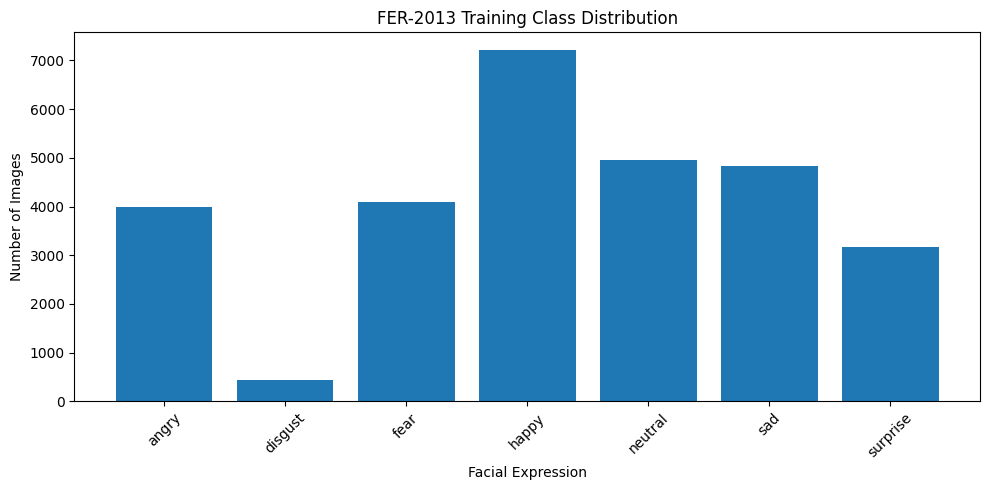

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())

plt.title("FER-2013 Training Class Distribution")
plt.xlabel("Facial Expression")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

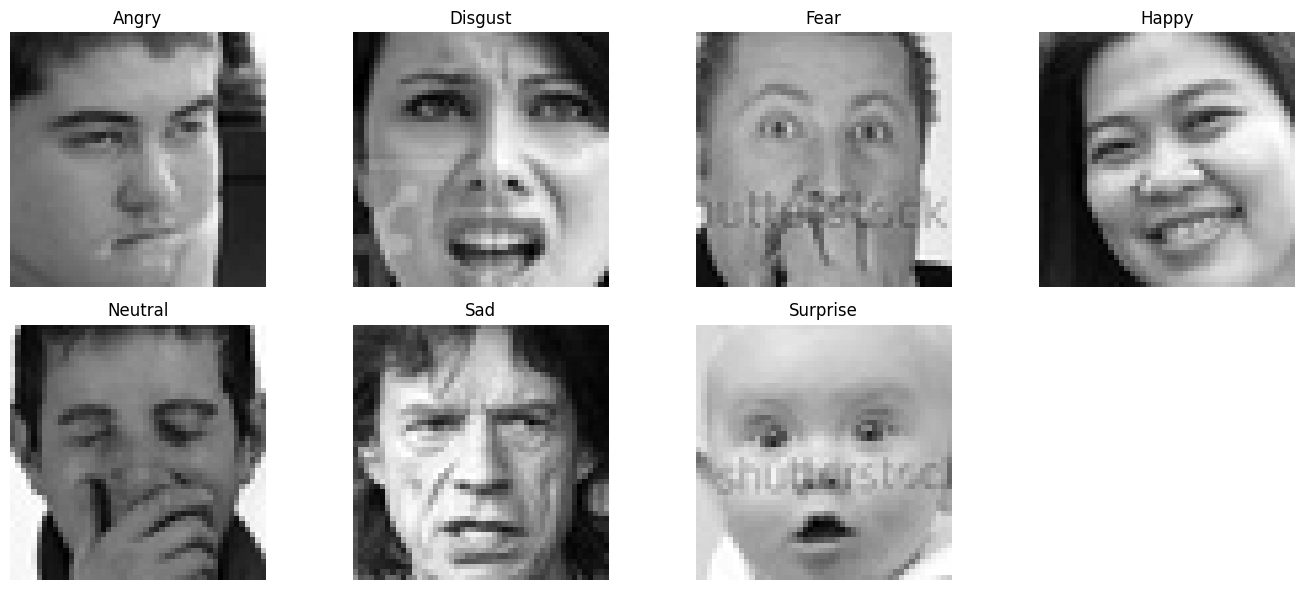

In [11]:
from PIL import Image
import random

classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(14, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)

    image_files = os.listdir(class_path)
    random_image = random.choice(image_files)

    img = Image.open(
        os.path.join(class_path, random_image)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(class_name.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
sample_class = classes[0]
sample_file = os.listdir(
    os.path.join(TRAIN_DIR, sample_class)
)[0]

sample_path = os.path.join(
    TRAIN_DIR,
    sample_class,
    sample_file
)

img = Image.open(sample_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (48, 48)
Image mode: L


In [13]:
from collections import Counter

size_counter = Counter()
mode_counter = Counter()

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    for filename in os.listdir(class_path):
        file_path = os.path.join(class_path, filename)

        try:
            with Image.open(file_path) as img:
                size_counter[img.size] += 1
                mode_counter[img.mode] += 1
        except Exception as e:
            print("Problem image:", file_path)

print("Image sizes:")
print(size_counter)

print("\nImage modes:")
print(mode_counter)

Image sizes:
Counter({(48, 48): 28709})

Image modes:
Counter({'L': 28709})


In [14]:
SEED = 42

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

VALIDATION_SPLIT = 0.20

In [15]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [16]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

Found 7178 files belonging to 7 classes.


In [17]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [19]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="data_augmentation")

In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [21]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [22]:
from tensorflow.keras import Model

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    7,
    activation="softmax"
)(x)

model = Model(
    inputs,
    outputs,
    name="FER2013_VGG16"
)

In [23]:
model.summary()

Model: "FER2013_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

In [26]:
EPOCHS = 20

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 140s 181ms/step - accuracy: 0.3442 - loss: 1.7486 - val_accuracy: 0.4367 - val_loss: 1.4887 - learning_rate: 0.0010
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 126s 175ms/step - accuracy: 0.4097 - loss: 1.5464 - val_accuracy: 0.4355 - val_loss: 1.4548 - learning_rate: 0.0010
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 126s 176ms/step - accuracy: 0.4261 - loss: 1.4959 - val_accuracy: 0.4659 - val_loss: 1.4203 - learning_rate: 0.0010
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 126s 176ms/step - accuracy: 0.4406 - loss: 1.4691 - val_accuracy: 0.4646 - val_loss: 1.4093 - learning_rate: 0.0010
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 126s 175ms/step - accuracy: 0.4440 - loss: 1.4557 - val_accuracy: 0.4713 - val_loss: 1.3890 - learning_rate: 0.0010
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 125s 175ms/step - accuracy: 0.4497 - loss: 1.4399 - val_accuracy: 0.4635 - val_loss: 1.3917 - learning_rate: 0.0010
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 126s 175ms/step - accura

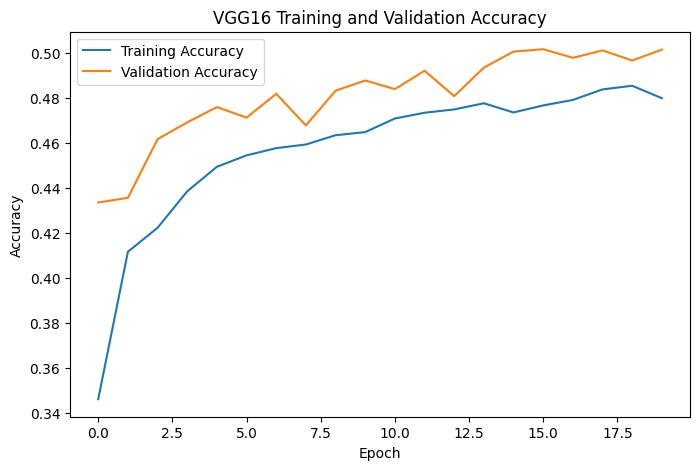

In [ ]:
history = history_phase1.history

plt.figure(figsize=(8, 5))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Training and Validation Accuracy")
plt.legend()
plt.show()

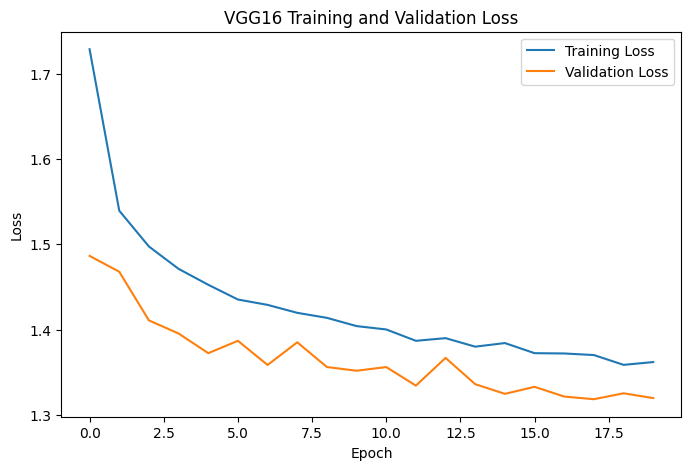

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training and Validation Loss")
plt.legend()
plt.show()

In [27]:
base_model.trainable = True

In [29]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [30]:
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 156s 213ms/step - accuracy: 0.5224 - loss: 1.2829 - val_accuracy: 0.5537 - val_loss: 1.1841 - learning_rate: 1.0000e-05
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 168s 233ms/step - accuracy: 0.5499 - loss: 1.2020 - val_accuracy: 0.5692 - val_loss: 1.1493 - learning_rate: 1.0000e-05
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 152s 211ms/step - accuracy: 0.5678 - loss: 1.1584 - val_accuracy: 0.5778 - val_loss: 1.1060 - learning_rate: 1.0000e-05
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 167s 233ms/step - accuracy: 0.5829 - loss: 1.1156 - val_accuracy: 0.5891 - val_loss: 1.1072 - learning_rate: 1.0000e-05
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 152s 211ms/step - accuracy: 0.5960 - loss: 1.0865 - val_accuracy: 0.6036 - val_loss: 1.0759 - learning_rate: 1.0000e-05
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 151s 210ms/step - accuracy: 0.6014 - loss: 1.0606 - val_accuracy: 0.5969 - val_loss: 1.0751 - learning_rate: 1.0000e-05
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 

In [33]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 34s 149ms/step - accuracy: 0.6170 - loss: 1.0240
Test Loss: 1.0240249633789062
Test Accuracy: 0.6170242428779602


In [34]:
import numpy as np

predictions = model.predict(test_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_ds
])

print("Predictions:", len(y_pred))
print("True labels:", len(y_true))

225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 138ms/step
Predictions: 7178
True labels: 7178


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.5602    0.4854    0.5201       958
     disgust     0.8000    0.0360    0.0690       111
        fear     0.4780    0.2969    0.3663      1024
       happy     0.8366    0.8512    0.8438      1774
     neutral     0.5541    0.6732    0.6078      1233
         sad     0.4436    0.5830    0.5038      1247
    surprise     0.7699    0.7088    0.7381       831

    accuracy                         0.6170      7178
   macro avg     0.6346    0.5192    0.5213      7178
weighted avg     0.6235    0.6170    0.6087      7178



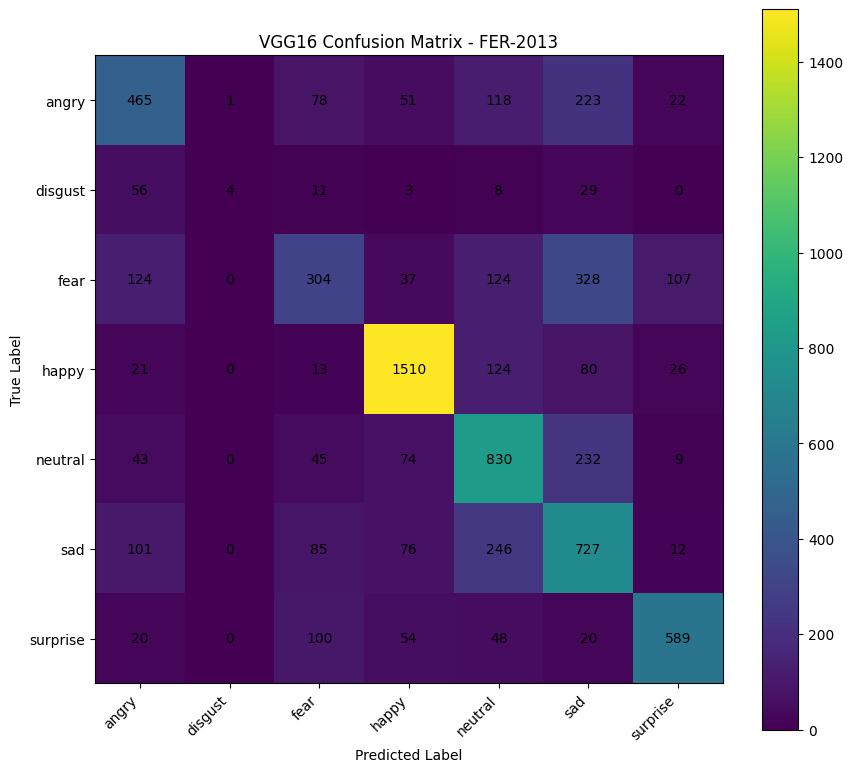

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(cm)

ax.set_xticks(
    range(len(class_names)),
    labels=class_names,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(class_names)),
    labels=class_names
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("VGG16 Confusion Matrix - FER-2013")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import roc_auc_score

y_true_onehot = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

macro_auc = roc_auc_score(
    y_true_onehot,
    predictions,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true_onehot,
    predictions,
    multi_class="ovr",
    average="weighted"
)

print("Macro ROC-AUC:", macro_auc)
print("Weighted ROC-AUC:", weighted_auc)

Macro ROC-AUC: 0.8944656427913487
Weighted ROC-AUC: 0.8927130148038038


In [38]:
wrong_indices = np.where(
    y_pred != y_true
)[0]

print(
    "Number of incorrect predictions:",
    len(wrong_indices)
)

Number of incorrect predictions: 2749


In [39]:
total_params = model.count_params()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 14847815
Trainable parameters: 7212551


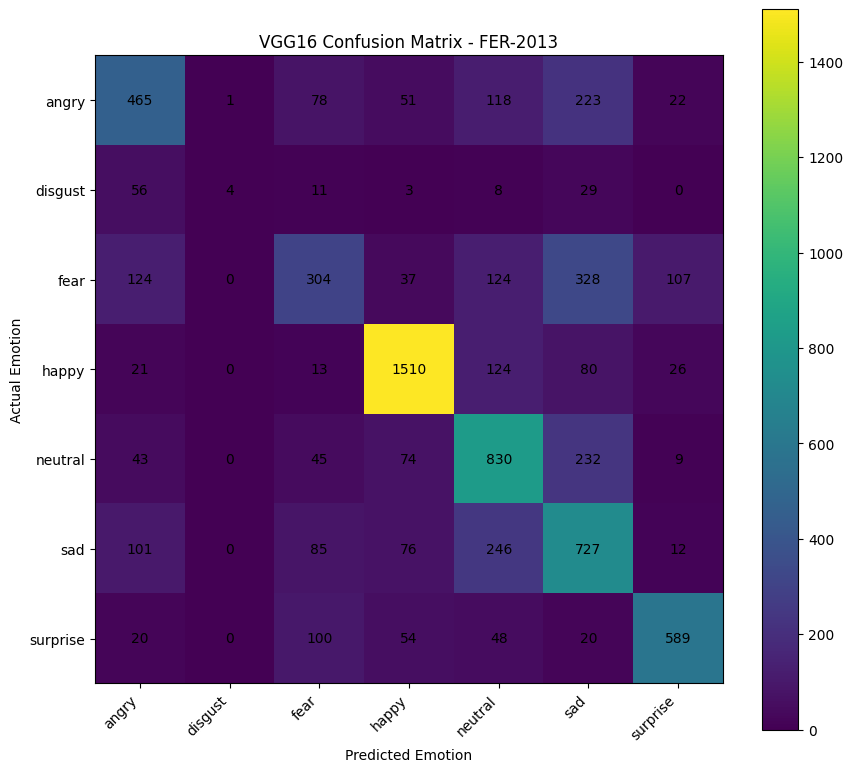

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(cm)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Emotion")
ax.set_ylabel("Actual Emotion")
ax.set_title("VGG16 Confusion Matrix - FER-2013")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [41]:
model_save_path = "/content/drive/MyDrive/SE4050_FER_Project/VGG16_FER2013_Final.keras"

model.save(model_save_path)

print("Model saved successfully:")
print(model_save_path)

Model saved successfully:
/content/drive/MyDrive/SE4050_FER_Project/VGG16_FER2013_Final.keras


In [42]:
import os

print("Model exists:", os.path.exists(model_save_path))

size_mb = os.path.getsize(model_save_path) / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model exists: True
Model size: 111.78 MB


In [43]:
loaded_model = tf.keras.models.load_model(model_save_path)

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    test_ds,
    verbose=0
)

print("Reloaded Model Accuracy:", loaded_accuracy)
print("Original Accuracy:", test_accuracy)

Reloaded Model Accuracy: 0.6170242428779602
Original Accuracy: 0.6170242428779602


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),

    "Macro Precision": precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )
}

for metric, value in final_metrics.items():
    print(f"{metric:20s}: {value:.4f}")

Accuracy            : 0.6170
Macro Precision     : 0.6346
Macro Recall        : 0.5192
Macro F1            : 0.5213
Weighted F1         : 0.6087


In [45]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["VGG16"],
    "Test Accuracy": [final_metrics["Accuracy"]],
    "Macro Precision": [final_metrics["Macro Precision"]],
    "Macro Recall": [final_metrics["Macro Recall"]],
    "Macro F1": [final_metrics["Macro F1"]],
    "Weighted F1": [final_metrics["Weighted F1"]],
    "Test Loss": [test_loss],
    "Total Parameters": [total_params],
    "Trainable Parameters": [trainable_params]
})

metrics_df

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Test Loss,Total Parameters,Trainable Parameters
0,VGG16,0.617024,0.634623,0.519203,0.521274,0.608664,1.024025,14847815,7212551


In [46]:
metrics_path = "/content/drive/MyDrive/SE4050_FER_Project/VGG16_Final_Metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Metrics saved.")

Metrics saved.


In [47]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Correct predictions:", np.sum(y_true == y_pred))
print("Incorrect predictions:", len(wrong_indices))
print("Total predictions:", len(y_true))

Correct predictions: 4429
Incorrect predictions: 2749
Total predictions: 7178
